# NOTE:
#### Check the latest version of this notebook to proceed with the pipeline. This notebook engineers the features of dataset "train_v1.parquet"
---

# Idea

This notebook's goal is feature engineering using:
- seaborn feature correlation heatmap,
- XGBoost feature importance method (*),
- SHAP analysis.

*This requires calling a diagnostic XGBoost model. The model will account for class imbalance \[95/5\]. The experiment will be saved using mlflow "simbox_fraud_detection" which will track the whole project.

---

### Imports

In [1]:
from pathlib import Path

import mlflow
import mlflow.xgboost

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import shap

from xgboost import XGBClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

### Paths and MLflow

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v1.parquet"

mlflow.set_tracking_uri(
    f"file:{PROJECT_ROOT / 'mlruns'}"
)

mlflow.set_experiment(
    "simbox_fraud_detection"
)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/12 23:09:43 INFO mlflow.tracking.fluent: Experiment with name 'simbox_fraud_detection' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load datasets

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)

print(train_df.shape)

train_df.head()

# Features and Target

X = train_df.drop(
    columns=[
        "label",
        "msisdn",
        "profile_date"
    ],
    errors="ignore"
)

y = train_df["label"]

print(X.shape)

(300164, 19)
(300164, 16)


---
### Correlation Heatmap

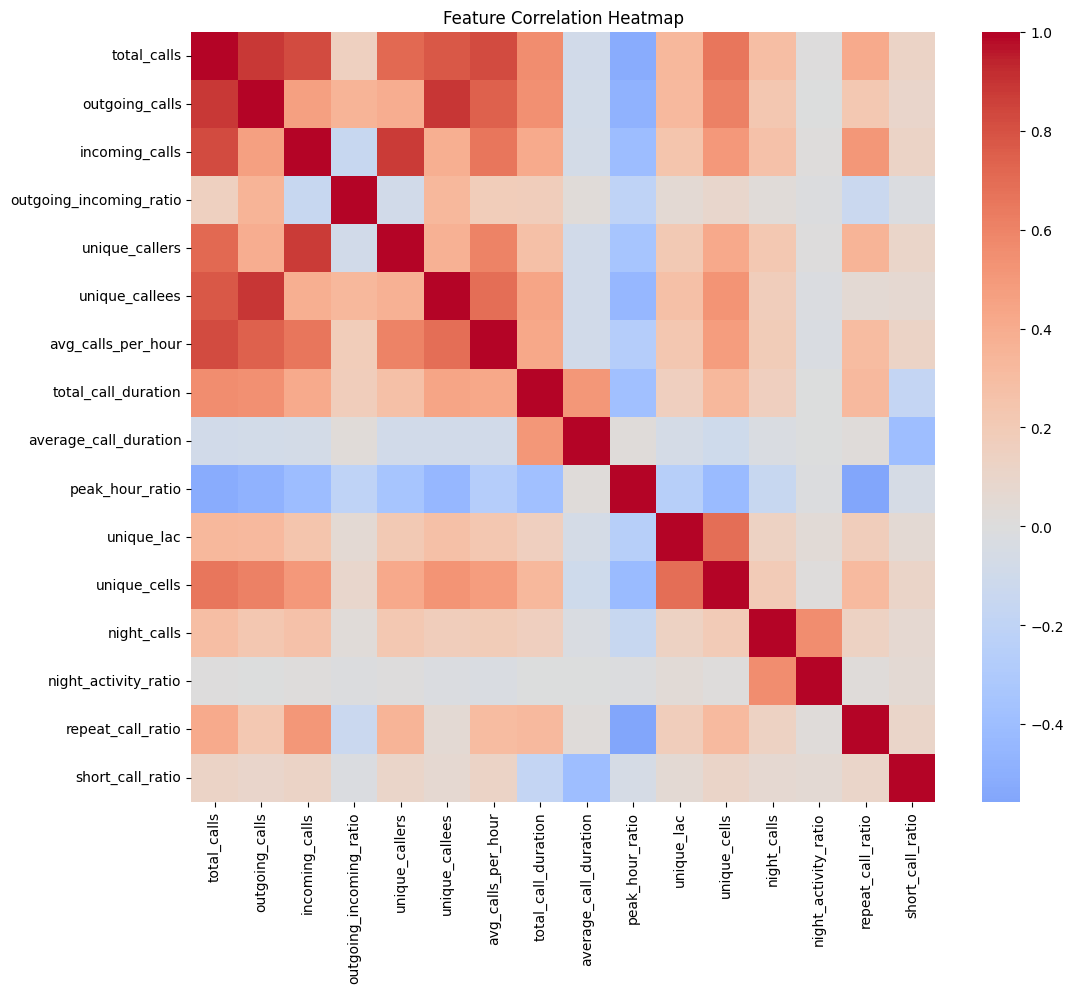

In [4]:
plt.figure(figsize=(12, 10))

corr = X.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

Correlation table

In [6]:
# Compute correlation matrix
corr_matrix = X.corr(numeric_only=True)

# Unstack to feature-pair format
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[
    corr_pairs["feature_1"] != corr_pairs["feature_2"]
]

# Take absolute value for ranking strength
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Sort by strongest correlations
corr_pairs = corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
)

# Remove duplicate pairs (A-B vs B-A)
corr_pairs["sorted_pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("sorted_pair")

# Final output
corr_pairs = corr_pairs.drop(columns=["sorted_pair"])

display(corr_pairs.head(30))

,feature_1,feature_2,correlation,abs_correlation
21,outgoing_calls,unique_callees,0.893485,0.893485
16,outgoing_calls,total_calls,0.886402,0.886402
66,unique_callers,incoming_calls,0.877628,0.877628
6,total_calls,avg_calls_per_hour,0.822902,0.822902
2,total_calls,incoming_calls,0.820013,0.820013
80,unique_callees,total_calls,0.779153,0.779153
22,outgoing_calls,avg_calls_per_hour,0.745290,0.745290
64,unique_callers,total_calls,0.712195,0.712195
86,unique_callees,avg_calls_per_hour,0.694706,0.694706
186,unique_cells,unique_lac,0.690762,0.690762


---
### XGBoost feature importance

Set up baseline XGBoost and MLflow

In [7]:
fraud_count = (y == 1).sum()
normal_count = (y == 0).sum()

scale_pos_weight = (
    normal_count / fraud_count
)

with mlflow.start_run(
    run_name="xgboost_baseline_v1"
):

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

    pred_proba = model.predict_proba(X)[:, 1]

    pr_auc = average_precision_score(
        y,
        pred_proba
    )

    roc_auc = roc_auc_score(
        y,
        pred_proba
    )

    mlflow.log_metric(
        "pr_auc",
        pr_auc
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc
    )

    mlflow.xgboost.log_model(
        model,
        artifact_path="model"
    )

print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)

2026/06/12 23:15:44 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/06/12 23:15:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

PR-AUC: 0.39878052505861866
ROC-AUC: 0.8315520603919004


Compute feature importance

In [8]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    importance_df.head(20)
)

,feature,importance
14,repeat_call_ratio,0.374593
7,total_call_duration,0.157589
2,incoming_calls,0.114190
8,average_call_duration,0.064576
5,unique_callees,0.045960
10,unique_lac,0.030328
3,outgoing_incoming_ratio,0.025362
15,short_call_ratio,0.024179
0,total_calls,0.023264
9,peak_hour_ratio,0.021702


Feature importance plot

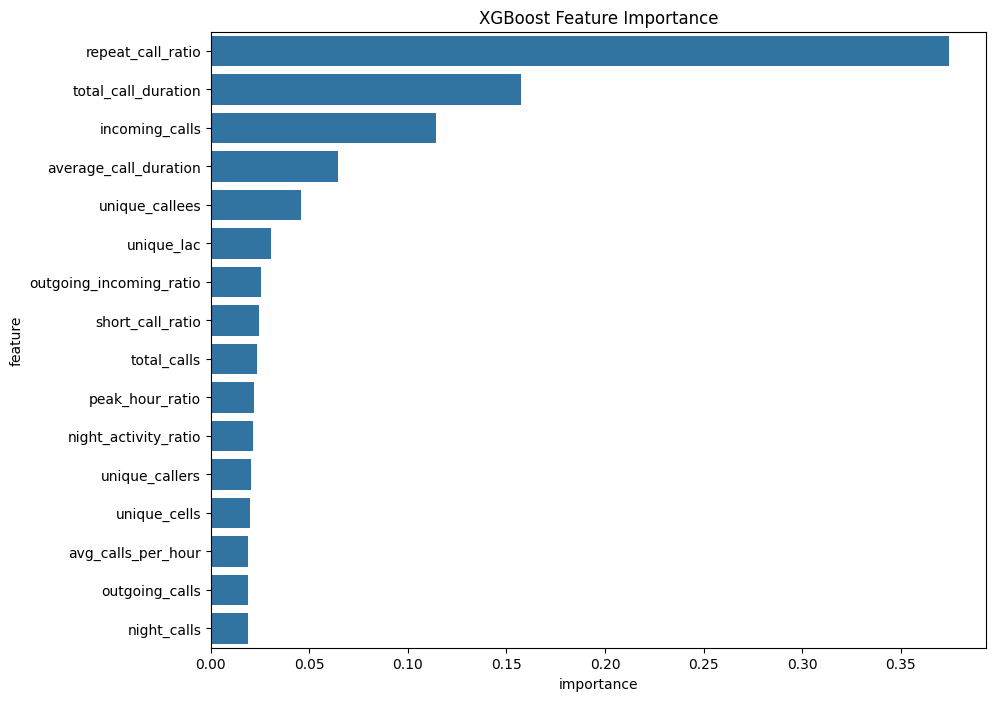

In [9]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

---
### SHAP analysis

In [10]:
sample_size = min(
    5000,
    len(X)
)

X_sample = X.sample(
    sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_sample
)

Summary plot

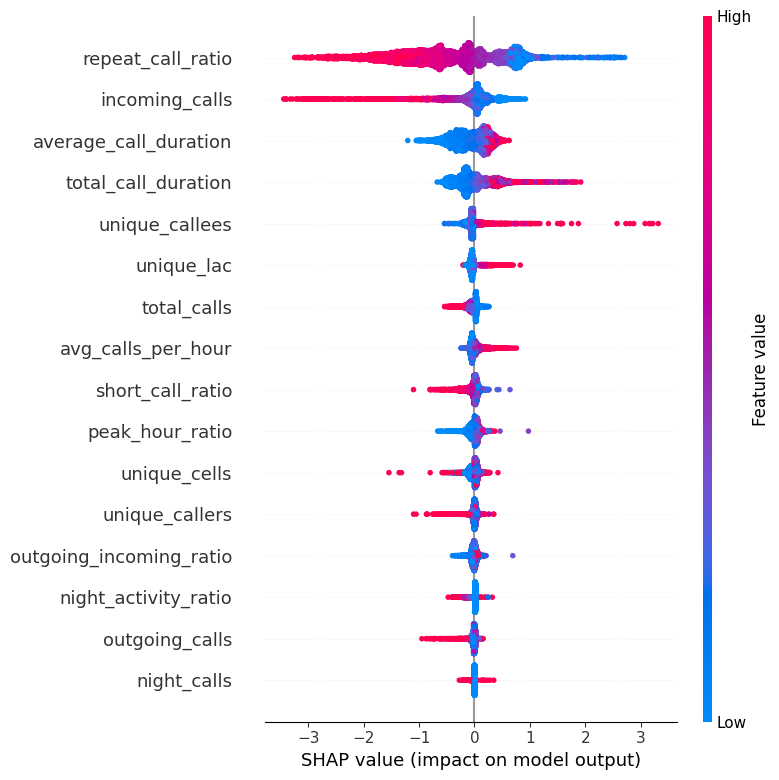

In [11]:
shap.summary_plot(
    shap_values,
    X_sample
)

Bar plot

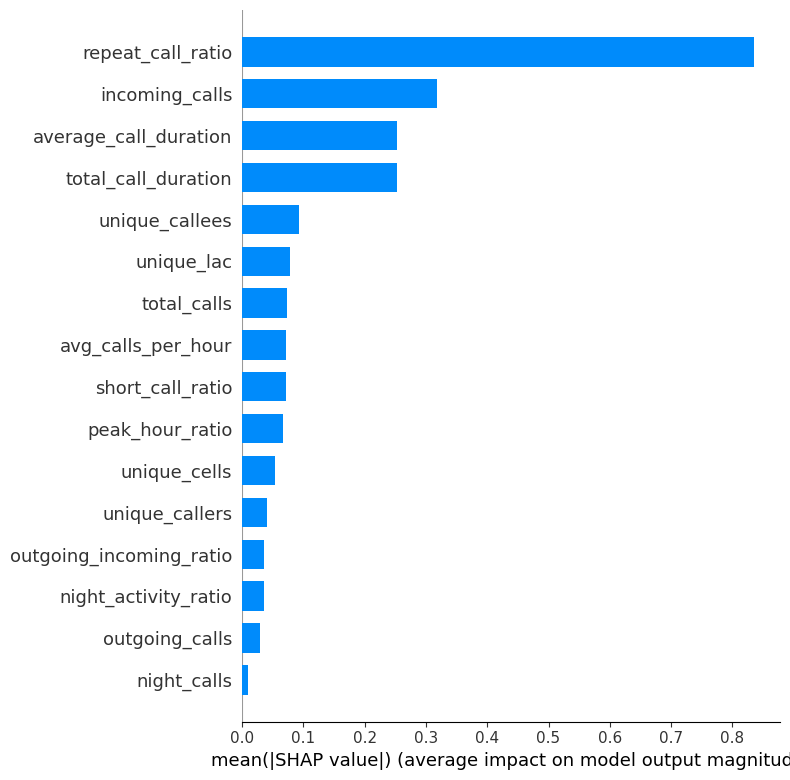

In [12]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

---
### Feature fixing

Ablation of the 6 least performing features `unique_cells`, `unique_callers`, `outgoing_incoming_ratio`, `night_activity_ratio`, `outgoing_calls`, `night_calls`.

In [13]:
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score

ablation_features = [
    "unique_cells",
    "unique_callers",
    "outgoing_incoming_ratio",
    "night_activity_ratio",
    "outgoing_calls",
    "night_calls"
]

# Smart ablation plan
ablation_sets = {
    "baseline": [],

    # Single-feature removals
    "drop_unique_cells": ["unique_cells"],
    "drop_unique_callers": ["unique_callers"],
    "drop_outgoing_incoming_ratio": ["outgoing_incoming_ratio"],
    "drop_night_activity_ratio": ["night_activity_ratio"],
    "drop_outgoing_calls": ["outgoing_calls"],
    "drop_night_calls": ["night_calls"],

    # Obvious redundant pairs
    "drop_redundant_features": [
        "night_calls",
        "outgoing_calls"
    ],

    # Aggressive candidate set
    "drop_all_candidates": ablation_features
}

# Holdout split for comparison
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

results = []

for run_name, dropped_features in ablation_sets.items():

    current_X_train = X_train.drop(
        columns=dropped_features,
        errors="ignore"
    )

    current_X_val = X_val.drop(
        columns=dropped_features,
        errors="ignore"
    )

    scale_pos_weight = (
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )

    with mlflow.start_run(
        run_name=f"ablation_{run_name}"
    ):

        mlflow.log_param(
            "ablation_features",
            ",".join(dropped_features)
        )

        model = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            current_X_train,
            y_train
        )

        pred_proba = model.predict_proba(
            current_X_val
        )[:, 1]

        pr_auc = average_precision_score(
            y_val,
            pred_proba
        )

        roc_auc = roc_auc_score(
            y_val,
            pred_proba
        )

        mlflow.log_metric(
            "pr_auc",
            pr_auc
        )

        mlflow.log_metric(
            "roc_auc",
            roc_auc
        )

        results.append({
            "run_name": run_name,
            "removed_features": dropped_features,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc
        })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "pr_auc",
        ascending=False
    )
)

display(results_df)

,run_name,removed_features,pr_auc,roc_auc
4,drop_night_activity_ratio,[night_activity_ratio],0.381676,0.808127
2,drop_unique_callers,[unique_callers],0.381565,0.807705
7,drop_redundant_features,"[night_calls, outgoing_calls]",0.381503,0.808236
3,drop_outgoing_incoming_ratio,[outgoing_incoming_ratio],0.381251,0.808318
5,drop_outgoing_calls,[outgoing_calls],0.381224,0.808075
6,drop_night_calls,[night_calls],0.381085,0.807716
0,baseline,[],0.380927,0.807690
8,drop_all_candidates,"[unique_cells, unique_callers, outgoing_incomi...",0.380507,0.806934
1,drop_unique_cells,[unique_cells],0.380223,0.806978
